# Detecting Rotation, Displacement, and Scaling in Image Pairs

This notebook trains a two-stream convolutional network to recognize which geometric transformations were applied to an image. Each example pairs a 224 × 224 image from the ADE20K scene-parsing dataset with a copy transformed by one, two, or all three of rotation, displacement, and scaling, and the label is the combination of transformations, encoded as an 8-way one-hot vector. The network, `changer`, passes both images through the same stem and four residual stages and exchanges features between the two streams after the second, third, and fourth stages; a fully connected head classifies the pooled features of both streams. The notebook trains the network, reports the loss and accuracy on the training, validation, and test sets, and breaks the validation accuracy down by the number of transformations.

## Setup

Download and unzip the ADE20K scene-parsing images (`ADEChallengeData2016.zip` for training and validation, `release_test.zip` for testing) and install `mmengine`, which provides the base class of the feature-exchange modules. The download runs only when the working directory has fewer than 4 entries. The next cell imports the libraries and selects the GPU if one is available.

In [1]:
# Download and unzip the ADE20K images and install mmengine
%%capture
import os
if len(os.listdir()) <4 :
  !wget http://data.csail.mit.edu/places/ADEchallenge/release_test.zip
  !wget http://data.csail.mit.edu/places/ADEchallenge/ADEChallengeData2016.zip
  !unzip ADEChallengeData2016.zip
  !unzip release_test.zip
  !pip install mmengine

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import glob
from os import path

from torch.utils.data import Dataset
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import random
from torch.utils.data import random_split

from random import randint
import matplotlib.pyplot as plt
from tqdm import tqdm
import torchvision.transforms.functional as F

BORDER_MODE= [cv2.BORDER_WRAP, cv2.BORDER_REFLECT, cv2.BORDER_REPLICATE,  cv2.BORDER_CONSTANT]

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")
dtype=torch.float32



Using cuda device


## Data Generation

Three functions apply geometric transformations to an image tensor of shape (H, W, 3) with values in [0, 1]:

- `displacement` shifts the image by a random offset of 20 to 100 pixels in either direction along each axis.
- `rotation` rotates the image about its center by a random angle of 15 to 60 degrees in either direction.
- `scaling` either zooms in by a random factor from 1.5 to 3 and crops the center, or pads the image by reflection and resizes it back to its original size, which zooms out.

All three fill the uncovered area by reflection (`cv2.BORDER_REFLECT`), so the transformed images have no black borders. `Brightness`, `bluring`, and `gaussian_noise` are photometric augmentations; the next cell shows every function on one training image, but the dataset uses only the three geometric transformations.

In [3]:
# Geometric transformations used by the dataset, followed by photometric augmentations
# Translation by a random offset along each axis
def displacement(img):
  (h, w) = img.shape[:2]
  img = img.numpy()
  # Shifts of 20 to 100 pixels in either direction along x and y
  (x, y) = (random_number(20,100) , random_number(20,100))
  # Translation matrix; the uncovered area is filled by reflection
  M = np.float32([[1, 0, x], [0, 1, y]])
  img = cv2.warpAffine(img, M, (w, h), borderMode = BORDER_MODE[1])
  img =  torch.from_numpy(img)
  return img

# Rotation about the image center
def rotation(img):
  # Angle of 15 to 60 degrees in either direction
  angle =  random_number(15,60)
  (h, w) = img.shape[:2]
  M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1)
  img = img.numpy()
  # Fill the uncovered corners by reflection, so no black borders appear
  img = cv2.warpAffine(img, M, (w, h), borderMode = BORDER_MODE[1])
  img =  torch.from_numpy(img)
  return img


# Zoom in (enlarge and center-crop) or zoom out (reflect-pad and shrink)
def scaling(img):
  (h, w) = img.shape[:2]
  # scale_type 1 zooms in, scale_type 0 zooms out
  scale_type = randint(0,1)
  scale = random.uniform(1.5, 3)
  if scale_type == 1 :
    img = img.permute(2,0,1)
    img = F.resize(img, [int(h*scale), int(w*scale)])
    crop = transforms.CenterCrop(min(w,h))
    img = crop(img)
    img = F.resize(img, [h, w])
  else:
    img = (img*255).numpy()
    img = cv2.copyMakeBorder(img, int(h*scale/8), int(h*scale/8), int(w*scale/8), int(w*scale/8),BORDER_MODE[1] )
    img =  torch.from_numpy(img)/255.0
    img = img.permute(2,0,1)
    img = F.resize(img, [h, w])

  img = img.permute(1,2,0)
  return img



# Photometric augmentations, shown below but not used by the dataset
def Brightness(img):
  # Brightness factor between 0.1 and 0.9 or between 1.1 and 1.9
  scale = 1 + random_number(10,90)/100
  img = img.permute(2,0,1)
  img = F.adjust_brightness(img, scale)
  img = img.permute(1,2,0)
  return img



def bluring(img):
  # Gaussian blur; a random odd value from 5 to 13 sets both the kernel size and sigma
  scale = random.randrange(5, 15, 2)
  img = img.permute(2,0,1)
  img = F.gaussian_blur( img,scale,scale)
  img = img.permute(1,2,0)
  return img

def gaussian_noise(img):
  # Additive Gaussian noise with a random standard deviation between 0.2 and 0.5
  scale = random.uniform(0.2, 0.5)
  noise = torch.randn_like(img) * scale
  img = img + noise

  return img


# Random integer between down and up, with a random sign
def random_number(down,up ):
    if random.choice([True, False]):
        return random.randint(-up, -down)
    else:
        return random.randint(down, up)


/usr/local/lib/python3.10/dist-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


Text(0.5, 1.0, 'gaussian_noise')

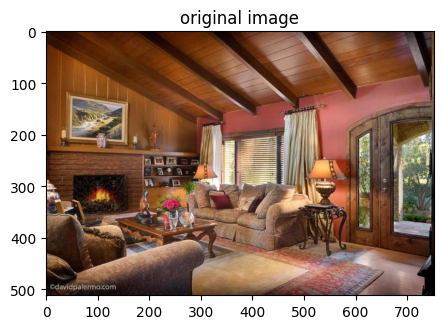

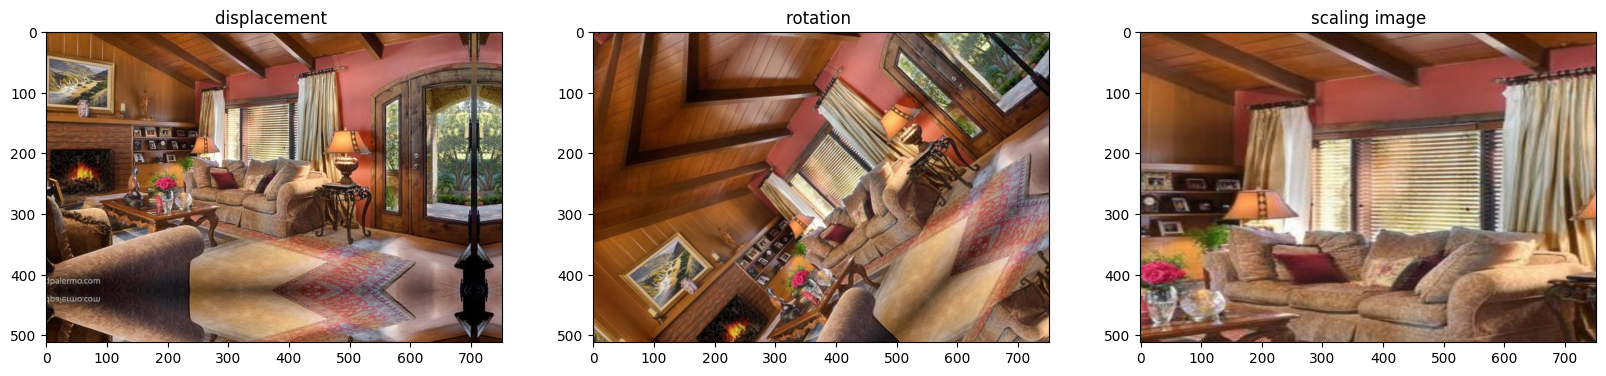

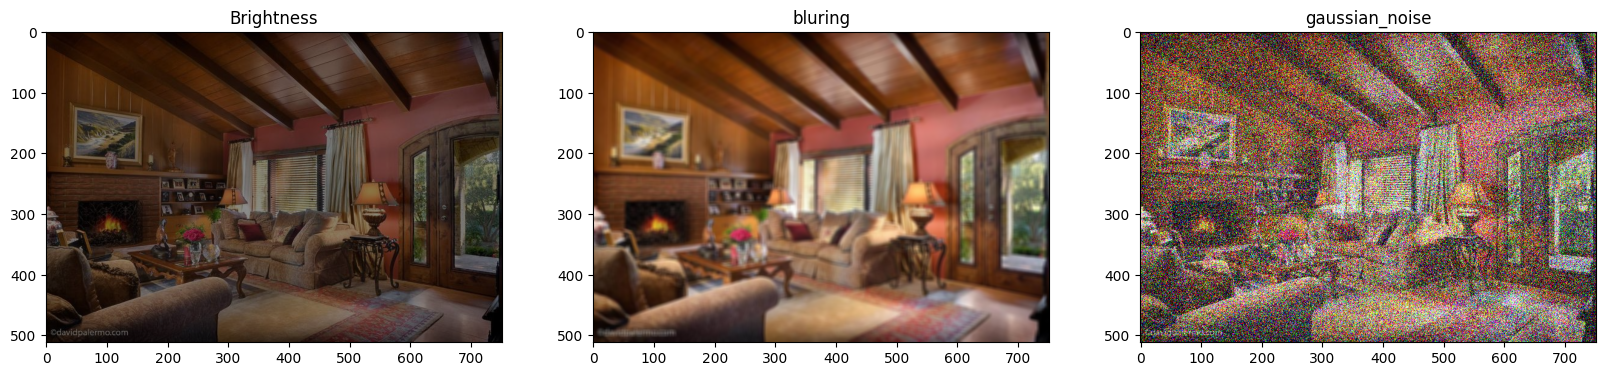

In [ ]:
# Apply every function to one training image
image = cv2.imread('./ADEChallengeData2016/images/training/ADE_train_00000652.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image =  torch.from_numpy(image)/255.0


_,axes = plt.subplots( 1,1, figsize=(5, 5))
axes.imshow(image)
axes.set_title('original image')



_,axes = plt.subplots( 1,3, figsize=(20, 5))

axes[0].imshow(displacement(image))
axes[0].set_title('displacement ')

axes[1].imshow(rotation(image))
axes[1].set_title('rotation ')

axes[2].imshow(scaling(image))
axes[2].set_title('scaling image')

_,axes = plt.subplots( 1,3, figsize=(20, 5))
axes[0].imshow(Brightness(image))
axes[0].set_title('Brightness')

axes[1].imshow(bluring(image))
axes[1].set_title('bluring')

axes[2].imshow(gaussian_noise(image))
axes[2].set_title('gaussian_noise')



`CustomDataset` reads an image, converts it to RGB, resizes it to 224 × 224, and scales it to [0, 1]. It applies 1, 2, or 3 distinct geometric transformations, chosen at random and applied in random order, to a copy of the image. The transformations used form a multi-hot vector [rotation, displacement, scaling], which is read as a binary number and one-hot encoded into 8 classes; class 0, no transformation, never occurs. The transformations are drawn each time an image is loaded, so every pass over a dataset produces new pairs.

The training set is the ADE20K training folder, in batches of 32. The validation and test sets are the ADE20K validation and test folders, in batches of 8. The last cell of this section shows eight pairs from the training loader and eight from the test loader.

In [4]:
# Pairs of an original image and a transformed copy, with an 8-way one-hot label
class CustomDataset(Dataset):
    def __init__(self, imgs_root, Type , transform=None):
        self.transform = transform
        self.Type  =Type
        self.path  = os.path.join(imgs_root,Type)

        self.imgs_name = os.listdir(self.path )

    def __len__(self):
        return len(self.imgs_name)

    def __getitem__(self, idx):
        img_path = os.path.join(self.path, self.imgs_name[idx])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (224, 224))
        image =  torch.from_numpy(image)/255.0

        trans_image = image

        # Apply 1, 2, or 3 distinct geometric transformations in random order
        functions = [ rotation , displacement ,scaling ]
        selected_functions= torch.tensor([0,0,0])
        n = randint(1,3)
        for func in random.sample(functions, n):
            trans_image = func(trans_image)
            index = functions.index(func)
            selected_functions[index] = 1

        # Read the multi-hot vector [rotation, displacement, scaling] as a binary number and one-hot encode it
        code = int(''.join(map(str, selected_functions.tolist())), 2)
        label = torch.zeros(8)
        label[code] = 1

        return image.permute(2,0,1) , trans_image.permute(2,0,1) , label

In [5]:
# ADE20K image folders
Root_train_valid = './ADEChallengeData2016/images/'
Root_test = './release_test/'
batch_size = 32
dataset_train = CustomDataset(Root_train_valid,'training')
dataset_test = CustomDataset(Root_test,'testing')
dataset_val = CustomDataset(Root_train_valid,'validation')

train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
test_loader= DataLoader(dataset_test, batch_size=8, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=8, shuffle=True)

['rotation', 'displacement', 'scaling']
['rotation', 'displacement', 'scaling']


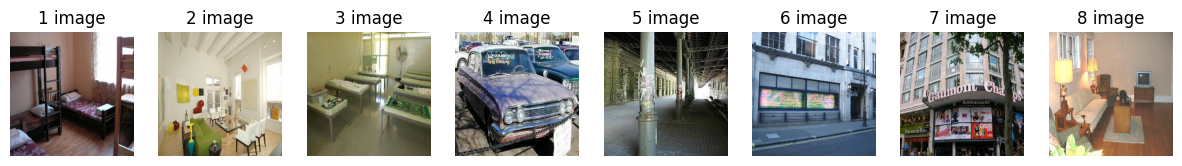

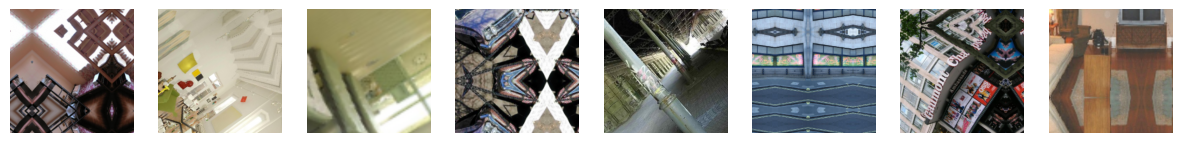

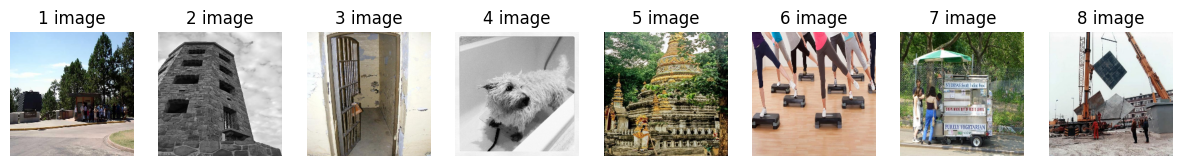

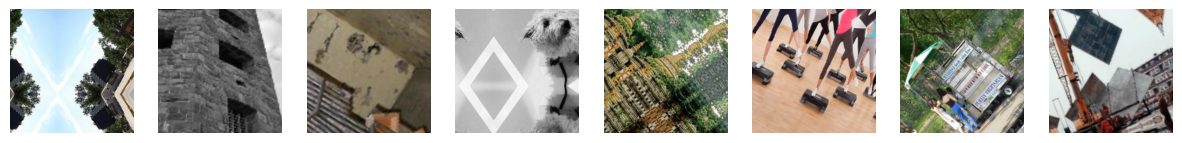

In [ ]:
# Show original images in one row and their transformed copies in the row below
def show_images(num_images,org , trans):
    print(['rotation' , 'displacement' , 'scaling' ])
    _,axes1 = plt.subplots( 1,num_images , figsize=(15, 5))
    _,axes2 = plt.subplots( 1,num_images , figsize=(15, 5))
    for i, ax in enumerate(axes1.flat):
        ax.imshow(org[i])
        ax.set_title(f'{i+1} image')
        ax.axis('off')

    for i, ax in enumerate(axes2.flat):
        ax.imshow(trans[i])
        ax.axis('off')


for i, data in enumerate(train_loader, 0):
    train_org, train_trans , train_label= data
    break

for i, data in enumerate(test_loader, 0):
    test_org, test_trans , test_label= data
    break

show_images(8,train_org.permute(0,2,3,1) , train_trans.permute(0,2,3,1))
show_images(8,test_org.permute(0,2,3,1) , test_trans.permute(0,2,3,1))

## Model

`changer` processes the original image and the transformed image with shared weights: a stem, then four stages with 64, 128, 256, and 512 output channels. A spatial exchange follows the second stage, and channel exchanges follow the third and fourth stages. The two 512-channel outputs are concatenated, average-pooled to a 1024-dimensional vector, and passed through a linear layer with 256 units, a sigmoid, a linear layer with 8 outputs, and a softmax.

`ChannelExchange` and `SpatialExchange` swap part of the features between the two streams. With the default `p = 1/2`, `ChannelExchange` swaps every second channel and `SpatialExchange` swaps every second column of the feature maps. Both subclass `BaseModule` from `mmengine`.

In [6]:
from mmengine.model import BaseModule
class ChannelExchange(BaseModule):
    """
    channel exchange
    Args:
        p (float, optional): p of the features will be exchanged.
            Defaults to 1/2.
    """
    def __init__(self, p=1/2):
        super().__init__()
        assert p >= 0 and p <= 1
        self.p = int(1/p)

    def forward(self, x1, x2):
        N, c, h, w = x1.shape

        exchange_map = torch.arange(c) % self.p == 0
        exchange_mask = exchange_map.unsqueeze(0).expand((N, -1))

        out_x1, out_x2 = torch.zeros_like(x1), torch.zeros_like(x2)
        out_x1[~exchange_mask, ...] = x1[~exchange_mask, ...]
        out_x2[~exchange_mask, ...] = x2[~exchange_mask, ...]
        out_x1[exchange_mask, ...] = x2[exchange_mask, ...]
        out_x2[exchange_mask, ...] = x1[exchange_mask, ...]

        return out_x1, out_x2



class SpatialExchange(BaseModule):
    """
    spatial exchange
    Args:
        p (float, optional): p of the features will be exchanged.
            Defaults to 1/2.
    """
    def __init__(self, p=1/2):
        super().__init__()
        assert p >= 0 and p <= 1
        self.p = int(1/p)

    def forward(self, x1, x2):
        N, c, h, w = x1.shape
        exchange_mask = torch.arange(w) % self.p == 0

        out_x1, out_x2 = torch.zeros_like(x1), torch.zeros_like(x2)
        out_x1[..., ~exchange_mask] = x1[..., ~exchange_mask]
        out_x2[..., ~exchange_mask] = x2[..., ~exchange_mask]
        out_x1[..., exchange_mask] = x2[..., exchange_mask]
        out_x2[..., exchange_mask] = x1[..., exchange_mask]

        return out_x1, out_x2

`block` is a residual block. Its main path is a 3 × 3 convolution, batch normalization, ReLU, dropout with probability 0.2, a second 3 × 3 convolution, and batch normalization. Its shortcut is a 1 × 1 convolution with no padding followed by batch normalization; the shortcut keeps the spatial size and changes the number of channels to that of the main path, so the two can be added. The sum passes through a ReLU and dropout with probability 0.2.

In [7]:
# Residual block: two 3x3 convolutions on the main path, a 1x1 convolution on the shortcut
class block(nn.Module):
  def __init__(self,input_channels, output_channels):
    super(block,self).__init__()
    self.left_stream = nn.Sequential(nn.Conv2d(input_channels , output_channels, kernel_size=(3,3), padding=1, stride=(1,1)) ,
                                      nn.BatchNorm2d(output_channels) ,
                                        nn.ReLU() , nn.Dropout(p=0.2) ,
                                        nn.Conv2d(output_channels, output_channels, kernel_size=(3,3), padding=1, stride=(1,1)) ,
                                         nn.BatchNorm2d(output_channels))
    self.right_stream = nn.Sequential(nn.Conv2d(input_channels , output_channels, kernel_size=(1,1), padding=0, stride=(1,1)) ,
                                       nn.BatchNorm2d(output_channels))
    self.Top = nn.Sequential(nn.ReLU() , nn.Dropout(p=0.2))

  def forward(self,x):
    s_r = self.right_stream(x)
    s_l = self.left_stream(x)
    out = self.Top(s_r  + s_l)
    return out

The stem is a 7 × 7 convolution with 64 channels and stride 2, batch normalization, ReLU, dropout with probability 0.2, and 3 × 3 max pooling with stride 2. Each stage has two blocks: the first keeps the number of channels, and the second changes it to the stage's output channels. All layers after the stem have stride 1, so the feature maps stay at 56 × 56 through all four stages.

In [8]:
# Two-stream network with shared weights and feature exchange between the streams
class changer(nn.Module):
  def __init__(self,block,SpatialExchange,ChannelExchange):
    super(changer,self).__init__()
    self.Fully = nn.Sequential(nn.Linear(1024, 256), nn.Sigmoid(),nn.Linear(256, 8),nn.Softmax(dim=1))

    self.steam=nn.Sequential(nn.Conv2d(3 , 64, kernel_size=(7,7), padding=3, stride=(2,2)),
                              nn.BatchNorm2d(64), nn.ReLU(), nn.Dropout(p=0.2),
                              nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

    self.block = block
    self.SpatialExchange = SpatialExchange()
    self.ChannelExchange = ChannelExchange()
    self.avrage_pool = nn.AdaptiveAvgPool2d((1,1))

    self.stage1= self._make_stage(64,64)
    self.stage2= self._make_stage(64,128)
    self.stage3= self._make_stage(128,256)
    self.stage4= self._make_stage(256,512)

  def _make_stage(self,input_channels , output_channels):
    block_1 = self.block(input_channels,input_channels)
    block_2 = self.block(input_channels,output_channels)
    layers=[block_1,block_2]
    return nn.Sequential(*layers)



  def forward(self,x1,x2):
    out_su = self.steam(x1)
    out_sd = self.steam(x2)
    out_s1u = self.stage1(out_su)
    out_s1d = self.stage1(out_sd)
    out_s2u = self.stage2(out_s1u)
    out_s2d = self.stage2(out_s1d)
    out_sEXu , out_sEXd = self.SpatialExchange(out_s2u ,out_s2d)
    out_s3u = self.stage3(out_sEXu)
    out_s3d = self.stage3(out_sEXd)
    out_cEX1u ,out_cEX1d = self.ChannelExchange(out_s3u,out_s3d)
    out_s4u = self.stage4(out_cEX1u)
    out_s4d = self.stage4(out_cEX1d)
    out_cEX2u , out_cEX2d = self.ChannelExchange(out_s4u,out_s4d)
    out_con =torch.cat((out_cEX2u, out_cEX2d), dim=1)
    out_pool = self.avrage_pool(out_con)
    in_fc = torch.flatten(out_pool, start_dim=1)
    out = self.Fully(in_fc)

    return out

Create the model on the selected device. The loss is binary cross-entropy between the softmax output and the one-hot label, and the optimizer is Adam with learning rate 0.001.

In [9]:
model = changer(block,SpatialExchange,ChannelExchange).to(device)

criterion = torch.nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Training and Validation

If `checkpoint.pth` exists, load the model and optimizer states from it. In the saved run the checkpoint existed, so the 10 epochs below continue an earlier training run. Each epoch trains on the training set, saves `checkpoint.pth`, and runs a validation pass. An example counts as correct when the largest output matches the label, and the printed loss is the sum of the batch-mean losses divided by the number of examples. The model stays in training mode and the validation pass runs without `torch.no_grad()`, so dropout is active during validation and the batch-normalization statistics are updated with validation images.

In [13]:
# Resume from checkpoint.pth when it exists
if 'checkpoint.pth' in os.listdir():
  checkpoint = torch.load('checkpoint.pth')
  model.load_state_dict(checkpoint['model_state_dict'])
  optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
  print('pre_train model is exist')
torch.cuda.empty_cache()

pre_train model is exist


In [ ]:
number_of_epoch = 10

for epoch in range(number_of_epoch):
  running_loss = 0
  total = 0
  correct = 0
  for raw_orgs, raw_trans ,raw_label in tqdm(train_loader, 0):
    torch.cuda.empty_cache()
    labels = raw_label.to(device)
    org = raw_orgs.to(device)
    trans = raw_trans.to(device)

    optimizer.zero_grad()

    predict = model(org ,trans)
    loss = criterion(predict, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    total += labels.size(0)

    # One-hot prediction at the largest output; correct when it equals the label
    _, max_indices = torch.max(predict.data, dim=1, keepdim=True)
    mask = torch.zeros_like(labels)
    predicted = mask.scatter_(1, max_indices, 1)

    correct += (torch.all(predicted == labels, dim=1)).sum().item()

  print(f'Training=>ecpoch:{epoch+1}, loss:{running_loss/ total} , accuracy:{100 * correct / total}')
  checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()}
  torch.save(checkpoint, 'checkpoint.pth')
  running_loss = 0
  total = 0
  correct = 0
  # Validation pass; the model stays in training mode
  for raw_orgs, raw_trans ,raw_label in tqdm(val_loader, 0):
    torch.cuda.empty_cache()
    labels = raw_label.to(device)
    org = raw_orgs.to(device)
    trans = raw_trans.to(device)
    predict = model(org ,trans)
    loss = criterion(predict, labels)
    running_loss += loss.item()
    total += labels.size(0)
    _, max_indices = torch.max(predict.data, dim=1, keepdim=True)
    mask = torch.zeros_like(labels)
    predicted = mask.scatter_(1, max_indices, 1)
    correct += (torch.all(predicted == labels, dim=1)).sum().item()
  print(f'Validation=>ecpoch:{epoch+1}, loss:{running_loss/ total} , accuracy:{100 * correct / total}')

print('Finished Training')

100%|██████████| 632/632 [17:53<00:00,  1.70s/it]


Training=>ecpoch:1, loss:0.005252140951755317 , accuracy:66.70460168233548


100%|██████████| 250/250 [00:59<00:00,  4.21it/s]


Validation=>ecpoch:1, loss:0.024605358872562648 , accuracy:58.75


100%|██████████| 632/632 [17:52<00:00,  1.70s/it]


...

Validation=>ecpoch:9, loss:0.02243090313859284 , accuracy:67.05


100%|██████████| 632/632 [21:06<00:00,  2.00s/it]


Training=>ecpoch:10, loss:0.00425401028984847 , accuracy:73.71598218703612


100%|██████████| 250/250 [01:00<00:00,  4.12it/s]

Validation=>ecpoch:10, loss:0.02042652072571218 , accuracy:68.15
Finished Training


## Test

Save the final model and optimizer state to `checkpoint.pth` and download the file with `google.colab.files`, then compute the loss and accuracy on the test set. As in validation, the model stays in training mode.

In [ ]:
# Save the final model and optimizer state and download the file from Colab
checkpoint = {
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': loss,
}

torch.save(checkpoint, 'checkpoint.pth')
from google.colab import files
files.download('checkpoint.pth')

In [14]:
# Loss and accuracy on the test set
correct = 0
running_loss = 0
total = 0
for raw_orgs, raw_trans ,raw_label in tqdm(test_loader, 0):
    torch.cuda.empty_cache()
    labels = raw_label.to(device)
    org = raw_orgs.to(device)
    trans = raw_trans.to(device)
    predict = model(org ,trans)
    loss = criterion(predict, labels)
    running_loss += loss.item()
    total += labels.size(0)
    _, max_indices = torch.max(predict.data, dim=1, keepdim=True)
    mask = torch.zeros_like(labels)
    predicted = mask.scatter_(1, max_indices, 1)
    correct += (torch.all(predicted == labels, dim=1)).sum().item()
print(f'Test=>loss:{running_loss/ total} , accuracy:{100 * correct / total}')


100%|██████████| 419/419 [01:48<00:00,  3.85it/s]

Test=>loss:0.02166514469061696 , accuracy:67.33293556085918


## Accuracy by Number of Transformations

Run the validation set again and group the accuracy by the number of transformations in each pair. The loader draws new random transformations, so these pairs differ from the ones in the validation pass above.

In [ ]:
correct_one_change , total_one_change = 0 ,0
correct_two_change , total_two_change = 0 ,0
correct_three_change , total_three_change = 0 ,0


for raw_orgs, raw_trans ,raw_label in tqdm(val_loader, 0):
    torch.cuda.empty_cache()
    labels = raw_label.to(device)
    org = raw_orgs.to(device)
    trans = raw_trans.to(device)
    predict = model(org ,trans)
    _, max_indices = torch.max(predict.data, dim=1, keepdim=True)
    mask = torch.zeros_like(labels)
    predicted = mask.scatter_(1, max_indices, 1)

    labels = labels.int().tolist()
    predicted = predicted.int().tolist()


    # One-hot classes 1, 2, and 4 are one transformation; 3, 5, and 6 are two; 7 is all three
    for i , lab in enumerate(labels ,0):

      if lab in [[0,1,0,0,0,0,0,0],[0,0,1,0,0,0,0,0],[0,0,0,0,1,0,0,0]] :
        total_one_change += 1
        if lab == predicted[i]: correct_one_change+=1

      elif lab in [[0,0,0,1,0,0,0,0],[0,0,0,0,0,1,0,0],[0,0,0,0,0,0,1,0]] :
        total_two_change += 1
        if lab == predicted[i]: correct_two_change+=1

      elif lab in [[0,0,0,0,0,0,0,1]] :
        total_three_change += 1
        if lab == predicted[i]: correct_three_change+=1

print(f'\ntotal one change:{total_one_change} , number of correct:{correct_one_change}, accuracy:{correct_one_change/total_one_change*100}')
print(f'total two change:{total_two_change} , number of correct:{correct_two_change}, accuracy:{correct_two_change/total_two_change*100}')
print(f'total three change:{total_three_change} , number of correct:{correct_three_change}, accuracy:{correct_three_change/total_three_change*100}')

100%|██████████| 250/250 [01:02<00:00,  4.00it/s]


total one change:645 , number of correct:502, accuracy:77.82945736434108
total two change:704 , number of correct:337, accuracy:47.86931818181818
total three change:651 , number of correct:530, accuracy:81.41321044546851


Pairs with one or three transformations are recognized more often than pairs with two: 77.83% of the 645 pairs with one transformation, 47.87% of the 704 pairs with two, and 81.41% of the 651 pairs with three.